[5.25183333e+01 4.22050000e+00 9.13333333e-02 6.00116667e+00
 2.97500000e-01 1.59000000e-01 1.73500000e-01 5.38833333e+00
 4.02666667e-01 1.92666667e-01 9.41666667e-02 1.25666667e-01
 2.35833333e-01 1.78000000e-01 2.36300000e+00 1.26263333e+01
 2.00000000e+00 1.48333333e-01 8.31183333e+00 1.32616667e+00
 1.09333333e-01 1.14333333e+00 2.96133333e+00 8.27583333e+00
 1.22916667e+00 1.85135000e+01 7.41666667e-01 6.58500000e-01
 5.90666667e-01 2.52166667e-01 7.00833333e-01 1.75953333e+01
 1.13441667e+01 1.35760000e+01 0.00000000e+00 2.45000000e-01
 8.62666667e-01 9.44500000e+00 4.08700000e+00 1.86386667e+01
 2.33250000e+00 8.31133333e+00 3.44558333e+01 6.28000000e+00
 6.09516667e+00 6.80433333e+00 3.27521667e+01 1.80200000e+00
 2.22410000e+01 3.78400000e+00 1.49700000e+01 7.19050000e+00
 2.38333333e+00 1.67783333e+00 1.81850000e+00 2.46563333e+01
 5.23333333e-01 9.31750000e+00 6.66833333e-01 2.38166667e-01
 5.81500000e-01 5.31883333e+00 4.53333333e-02 4.90916667e+00
 6.27683333e+00 2.056500

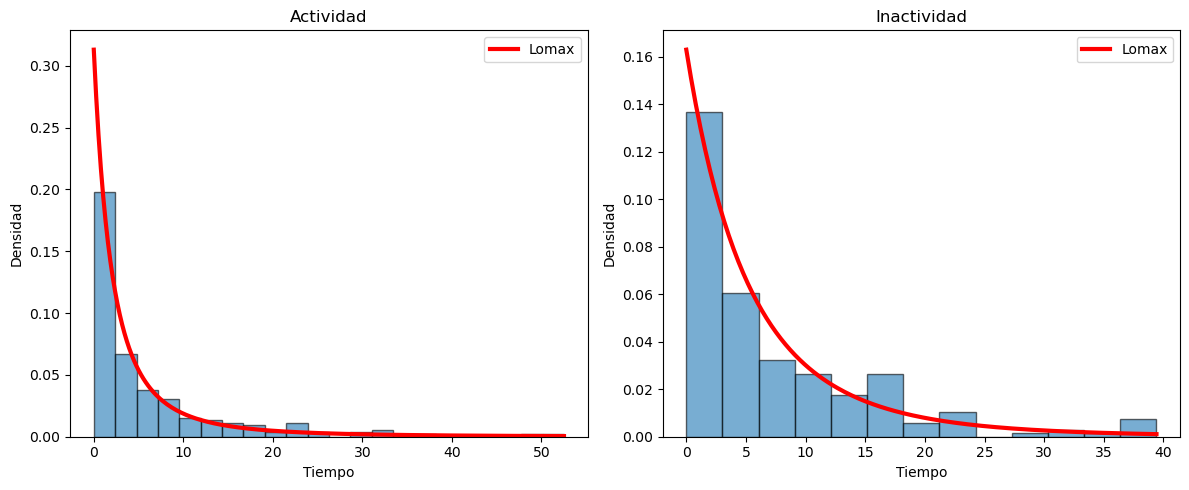

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import lomax
from scipy.stats import kstest

############################################################
# LEER ARCHIVO
############################################################

archivo = "Analisis_GATOS_LISTA2.xlsx"

df = pd.read_excel(archivo, sheet_name="Duraciones")

# Duraciones cuando el estado es ACTIVO
ACTIVO = df.loc[df["Estado"] == "ACTIVO", "Duracion_min"].dropna().to_numpy()

# Duraciones cuando el estado es INACTIVO
INACTIVO = df.loc[df["Estado"] == "INACTIVO", "Duracion_min"].dropna().to_numpy()

print(ACTIVO)

print("Número de tiempos activos:", len(ACTIVO))
print("Número de tiempos inactivos:", len(INACTIVO))


############################################################
# AJUSTE LOMAX
############################################################

# loc=0 porque los tiempos comienzan en cero

shape_A, loc_A, scale_A = lomax.fit(ACTIVO, floc=0)

shape_I, loc_I, scale_I = lomax.fit(INACTIVO, floc=0)

print("\nActividad")
print("----------------------")
print("alpha =", shape_A)
print("lambda =", scale_A)

print("\nInactividad")
print("----------------------")
print("alpha =", shape_I)
print("lambda =", scale_I)

print(shape_A/scale_A, 1/scale_A)
print(shape_I/scale_I, 1/scale_I)



############################################################
# TEST KOLMOGOROV-SMIRNOV
############################################################

KS_A = kstest(
    ACTIVO,
    'lomax',
    args=(shape_A, loc_A, scale_A)
)

KS_I = kstest(
    INACTIVO,
    'lomax',
    args=(shape_I, loc_I, scale_I)
)

print("\nKolmogorov-Smirnov")

print("\nActividad")
print(KS_A)

print("\nInactividad")
print(KS_I)

############################################################
# HISTOGRAMA + AJUSTE
############################################################

fig, ax = plt.subplots(1,2, figsize=(12,5))

##############################################

x = np.linspace(0,max(ACTIVO),200)

ax[0].hist(
    ACTIVO,
    bins='auto',
    density=True,
    alpha=0.6,
    edgecolor='k'
)

ax[0].plot(
    x,
    lomax.pdf(x, shape_A, loc_A, scale_A),
    'r',
    lw=3,
    label='Lomax'
)

ax[0].set_title("Actividad")
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("Densidad")
ax[0].legend()

##############################################

x = np.linspace(0,max(INACTIVO),200)

ax[1].hist(
    INACTIVO,
    bins='auto',
    density=True,
    alpha=0.6,
    edgecolor='k'
)

ax[1].plot(
    x,
    lomax.pdf(x, shape_I, loc_I, scale_I),
    'r',
    lw=3,
    label='Lomax'
)

ax[1].set_title("Inactividad")
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel("Densidad")
ax[1].legend()

plt.tight_layout()
plt.show()